# Importing Data

In [1]:

import sys
sys.path.append("home/565/pv3484/aus_substation_electricity")

%cd aus_substation_electricity/

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

In [74]:
import pandas as pd
from datetime import date, timedelta
from dateutil.easter import easter
import matplotlib.pyplot as plt
import numpy as np
import math


# Demand vs weather variables - general relationships
- all locations, all years, all days

## Demand vs temperature

In [10]:
# index are datetimes (demand and temp)
demand.index = pd.to_datetime(demand.index)
obs.index = pd.to_datetime(obs.index)

# Extract date
demand["date"] = demand.index.date
obs["date"] = obs.index.date

In [12]:
# getting a list of the actual substation power readings (ignoring date column)

substations = [c for c in demand.columns if c not in ["date"]]

In [23]:
# calculate daily mean demand per substation
daily_sub_demand = demand.groupby("date")[substations].mean()
daily_sub_demand = daily_sub_demand.dropna(how="any")
daily_demand = daily_sub_demand.mean(axis=1).rename("demand_mean").reset_index()

# gives system wide demand per day (mean across all locations)

In [29]:
# detect temperature
temp_col = next(c for c in obs.columns if ("t2" in c.lower()) or ("temp" in c.lower()))
# next(...) used instead of a list comprehension

temp_daily = (
    obs.groupby("date")[temp_col]
    .apply(lambda x: x.astype(float).mean())
    .rename("temp_mean")
    .reset_index()
)

# searches obs for any column containing t2m or temp

In [30]:
# merging demand and obs on date
merged = daily_demand.merge(temp_daily, on="date", how="left")

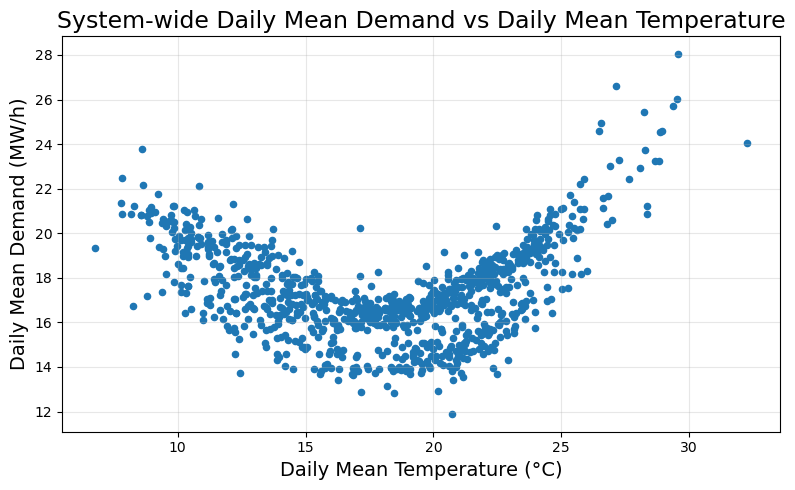

In [103]:
# plotting
plt.figure(figsize=(8,5))

plt.scatter(
    merged["temp_mean"],
    merged["demand_mean"],
    s=20
)

plt.title("System-wide Daily Mean Demand vs Daily Mean Temperature", fontsize=17)
plt.xlabel("Daily Mean Temperature (°C)", fontsize=14)
plt.ylabel("Daily Mean Demand (MW/h)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/home/565/pv3484/aus_substation_electricity/data/figures/thesis/data_methods/system_wide_mean_temp", dpi=300)
plt.show()

## Demand vs other weather variables

In [75]:
import glob

station_files = glob.glob("//home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v4/weather_station_*.csv")

# Exclude the combined file and the half-hourly file
station_files = [
    f for f in station_files 
    if "066022_066214" not in f 
    and "half_hourly" not in f
]
frames = []
for f in station_files:
    df = pd.read_csv(f, parse_dates=True, index_col=0)
    df["station"] = f.split("/")[-1].replace(".csv", "")  # tag with filename
    frames.append(df)

obs_all = pd.concat(frames)
obs_all.index = pd.to_datetime(obs_all.index)
obs_all["date"] = obs_all.index.date

In [90]:
merged_weather = daily_demand.merge(weather_daily, on="date", how="left")

plot_vars = ["temp", "dewpoint", "relative_humidity", "wind_speed_kmh", "precip_incremental"]

var_labels = {
    "temp": "Temperature (°C)",
    "dewpoint": "Dew Point (°C)",
    "relative_humidity": "Relative Humidity (%)",
    "wind_speed_kmh": "Wind Speed (km/h)",
    "precip_incremental": "Precipitation (mm)"
}

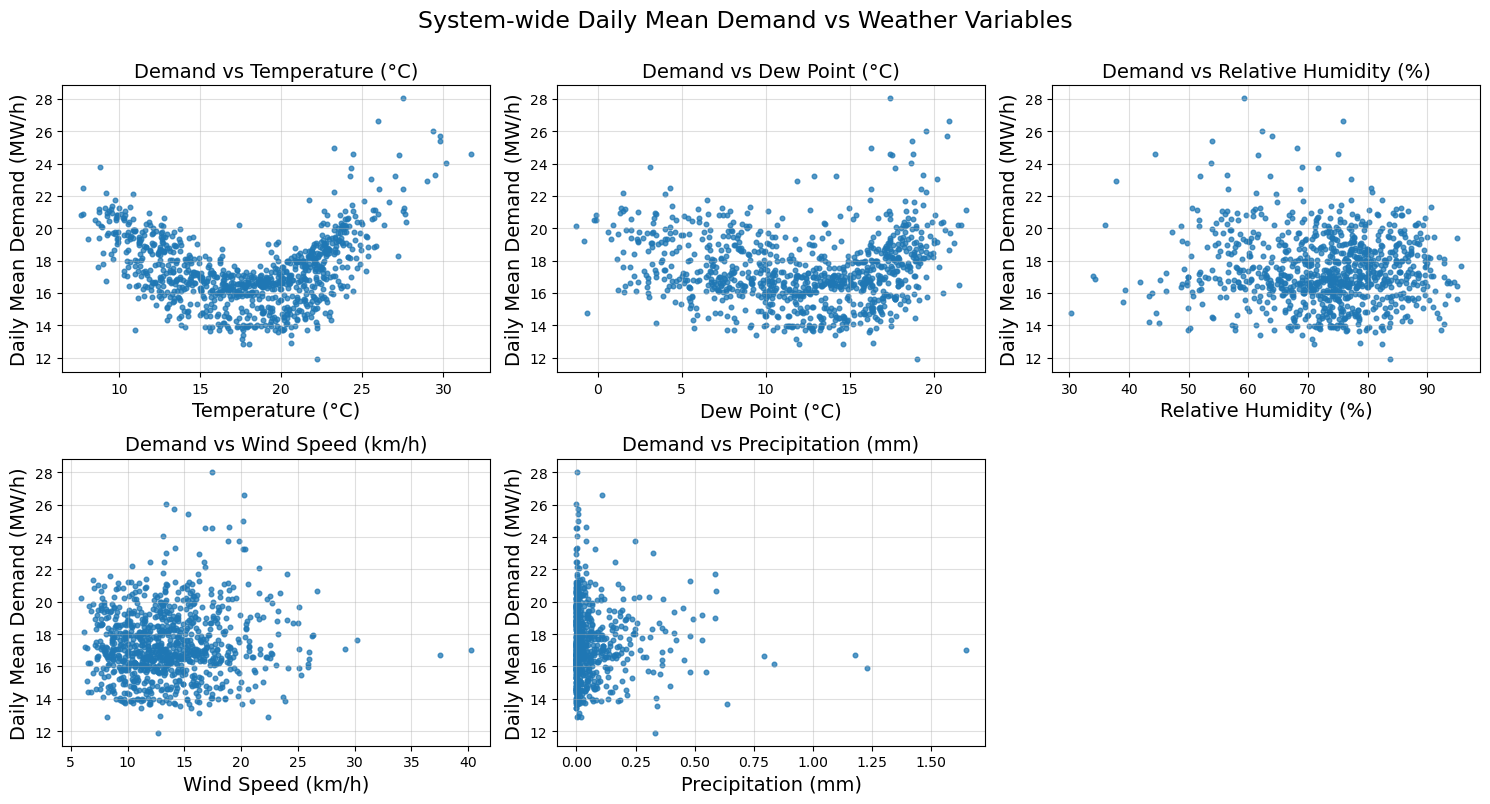

In [102]:
n = len(plot_vars)
ncols = 3
nrows = math.ceil(n / ncols)  # 2 rows for 5 variables

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    labels = var_labels[var]
    data = merged_weather[["demand_mean", var]].dropna()
    ax.scatter(data[var], data["demand_mean"], s=11, alpha=0.75)
    ax.set_xlabel(labels, fontsize=14)
    ax.set_ylabel("Daily Mean Demand (MW/h)", fontsize=14)
    ax.set_title(f"Demand vs {labels}", fontsize=14)
    ax.grid(alpha=0.4)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("System-wide Daily Mean Demand vs Weather Variables", y=1, fontsize=17)
plt.tight_layout()
plt.savefig("/home/565/pv3484/aus_substation_electricity/data/figures/thesis/data_methods/demand_vs_weather.png", dpi=300, bbox_inches="tight")
plt.show()

# Separating day type

In [105]:
# need to add a weekend/weekday flag to the weather dataframe

merged_weather["date"] = pd.to_datetime(merged_weather["date"])
merged_weather["is_weekend"] = merged_weather["date"].dt.dayofweek >= 5  # 5=Sat, 6=Sun

# define weekend from weekday
weekday = merged_weather[merged_weather["is_weekend"] == False]
weekend = merged_weather[merged_weather["is_weekend"] == True]

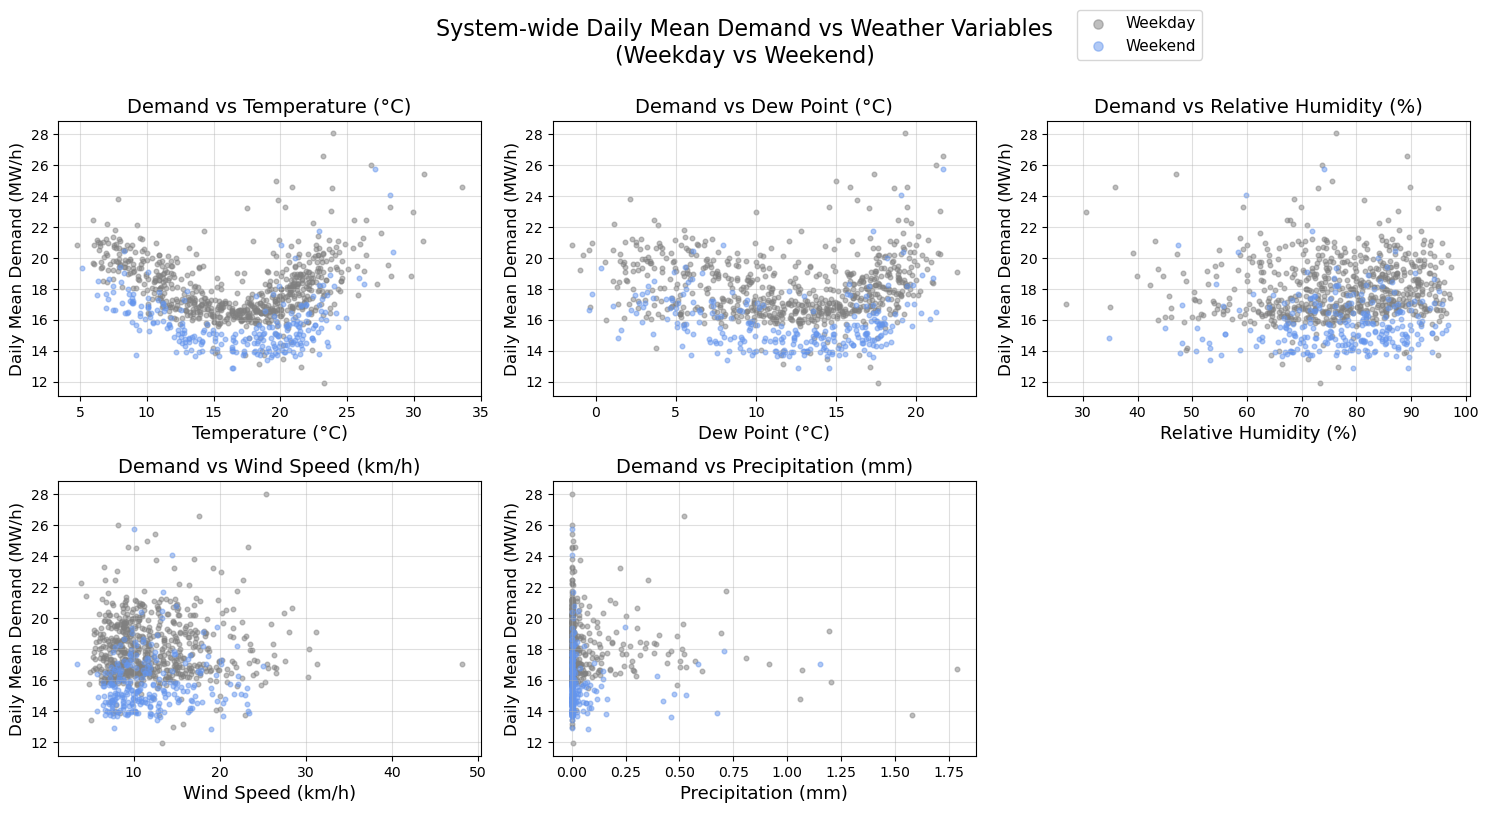

In [187]:
plot_vars = list(var_labels.keys())

n = len(plot_vars)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    label = var_labels[var]

    wd = weekday[["demand_mean", var]].dropna()
    we = weekend[["demand_mean", var]].dropna()

    ax.scatter(wd[var], wd["demand_mean"], s=11, alpha=0.5, color="grey", label="Weekday")
    ax.scatter(we[var], we["demand_mean"], s=11, alpha=0.5, color="cornflowerblue", label="Weekend")

    ax.set_xlabel(label, fontsize=13)
    ax.set_ylabel("Daily Mean Demand (MW/h)", fontsize=12)
    ax.set_title(f"Demand vs {label}", fontsize=14)
    ax.grid(alpha=0.4)


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("System-wide Daily Mean Demand vs Weather Variables\n(Weekday vs Weekend)", y=1, fontsize=16)
# after the for loop, before tight_layout
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.81, 1.02), markerscale=2, fontsize=11)

plt.tight_layout()
plt.savefig("/home/565/pv3484/aus_substation_electricity/data/figures/thesis/data_methods/demand_vs_weather_weekend_day.png", dpi=300, bbox_inches="tight")
plt.show()

# Demand and each weather variable
- separated into time blocks and weekend/weekday

In [153]:
blocks = {
    "00_04": range(0, 4),
    "04_08": range(4, 8),
    "08_15": range(8, 15),
    "15_20": range(15, 20),
    "20_24": range(20, 24),
}

block_labels = {
    "00_04": "00:00 - 04:00",
    "04_08": "04:00 - 08:00",
    "08_15": "08:00 - 15:00",
    "15_20": "15:00 - 20:00",
    "20_24": "20:00 - 24:00",
}

In [149]:
# assigning each time block to each row in obs
obs_all["hour"] = obs_all.index.hour

def assign_block(hour):
    for block_name, hours in blocks.items():
        if hour in hours:
            return block_name
    return None

obs_all["time_block"] = obs_all["hour"].map(assign_block)

In [150]:
# daily mean per variable per time block
weather_cols = ["temp", "dewpoint", "relative_humidity", "wind_speed_kmh", "precip_incremental"]

weather_block_daily = (
    obs_all.groupby(["date", "station", "time_block"])[weather_cols]
    .mean()
    .groupby(["date", "time_block"])
    .mean()
    .reset_index()
)

In [151]:
# merging with demand
weather_block_daily["date"] = pd.to_datetime(weather_block_daily["date"])
daily_demand["date"] = pd.to_datetime(daily_demand["date"])

merged_blocks = daily_demand.merge(weather_block_daily, on="date", how="left")

# Add weekend flag
merged_blocks["is_weekend"] = merged_blocks["date"].dt.dayofweek >= 5

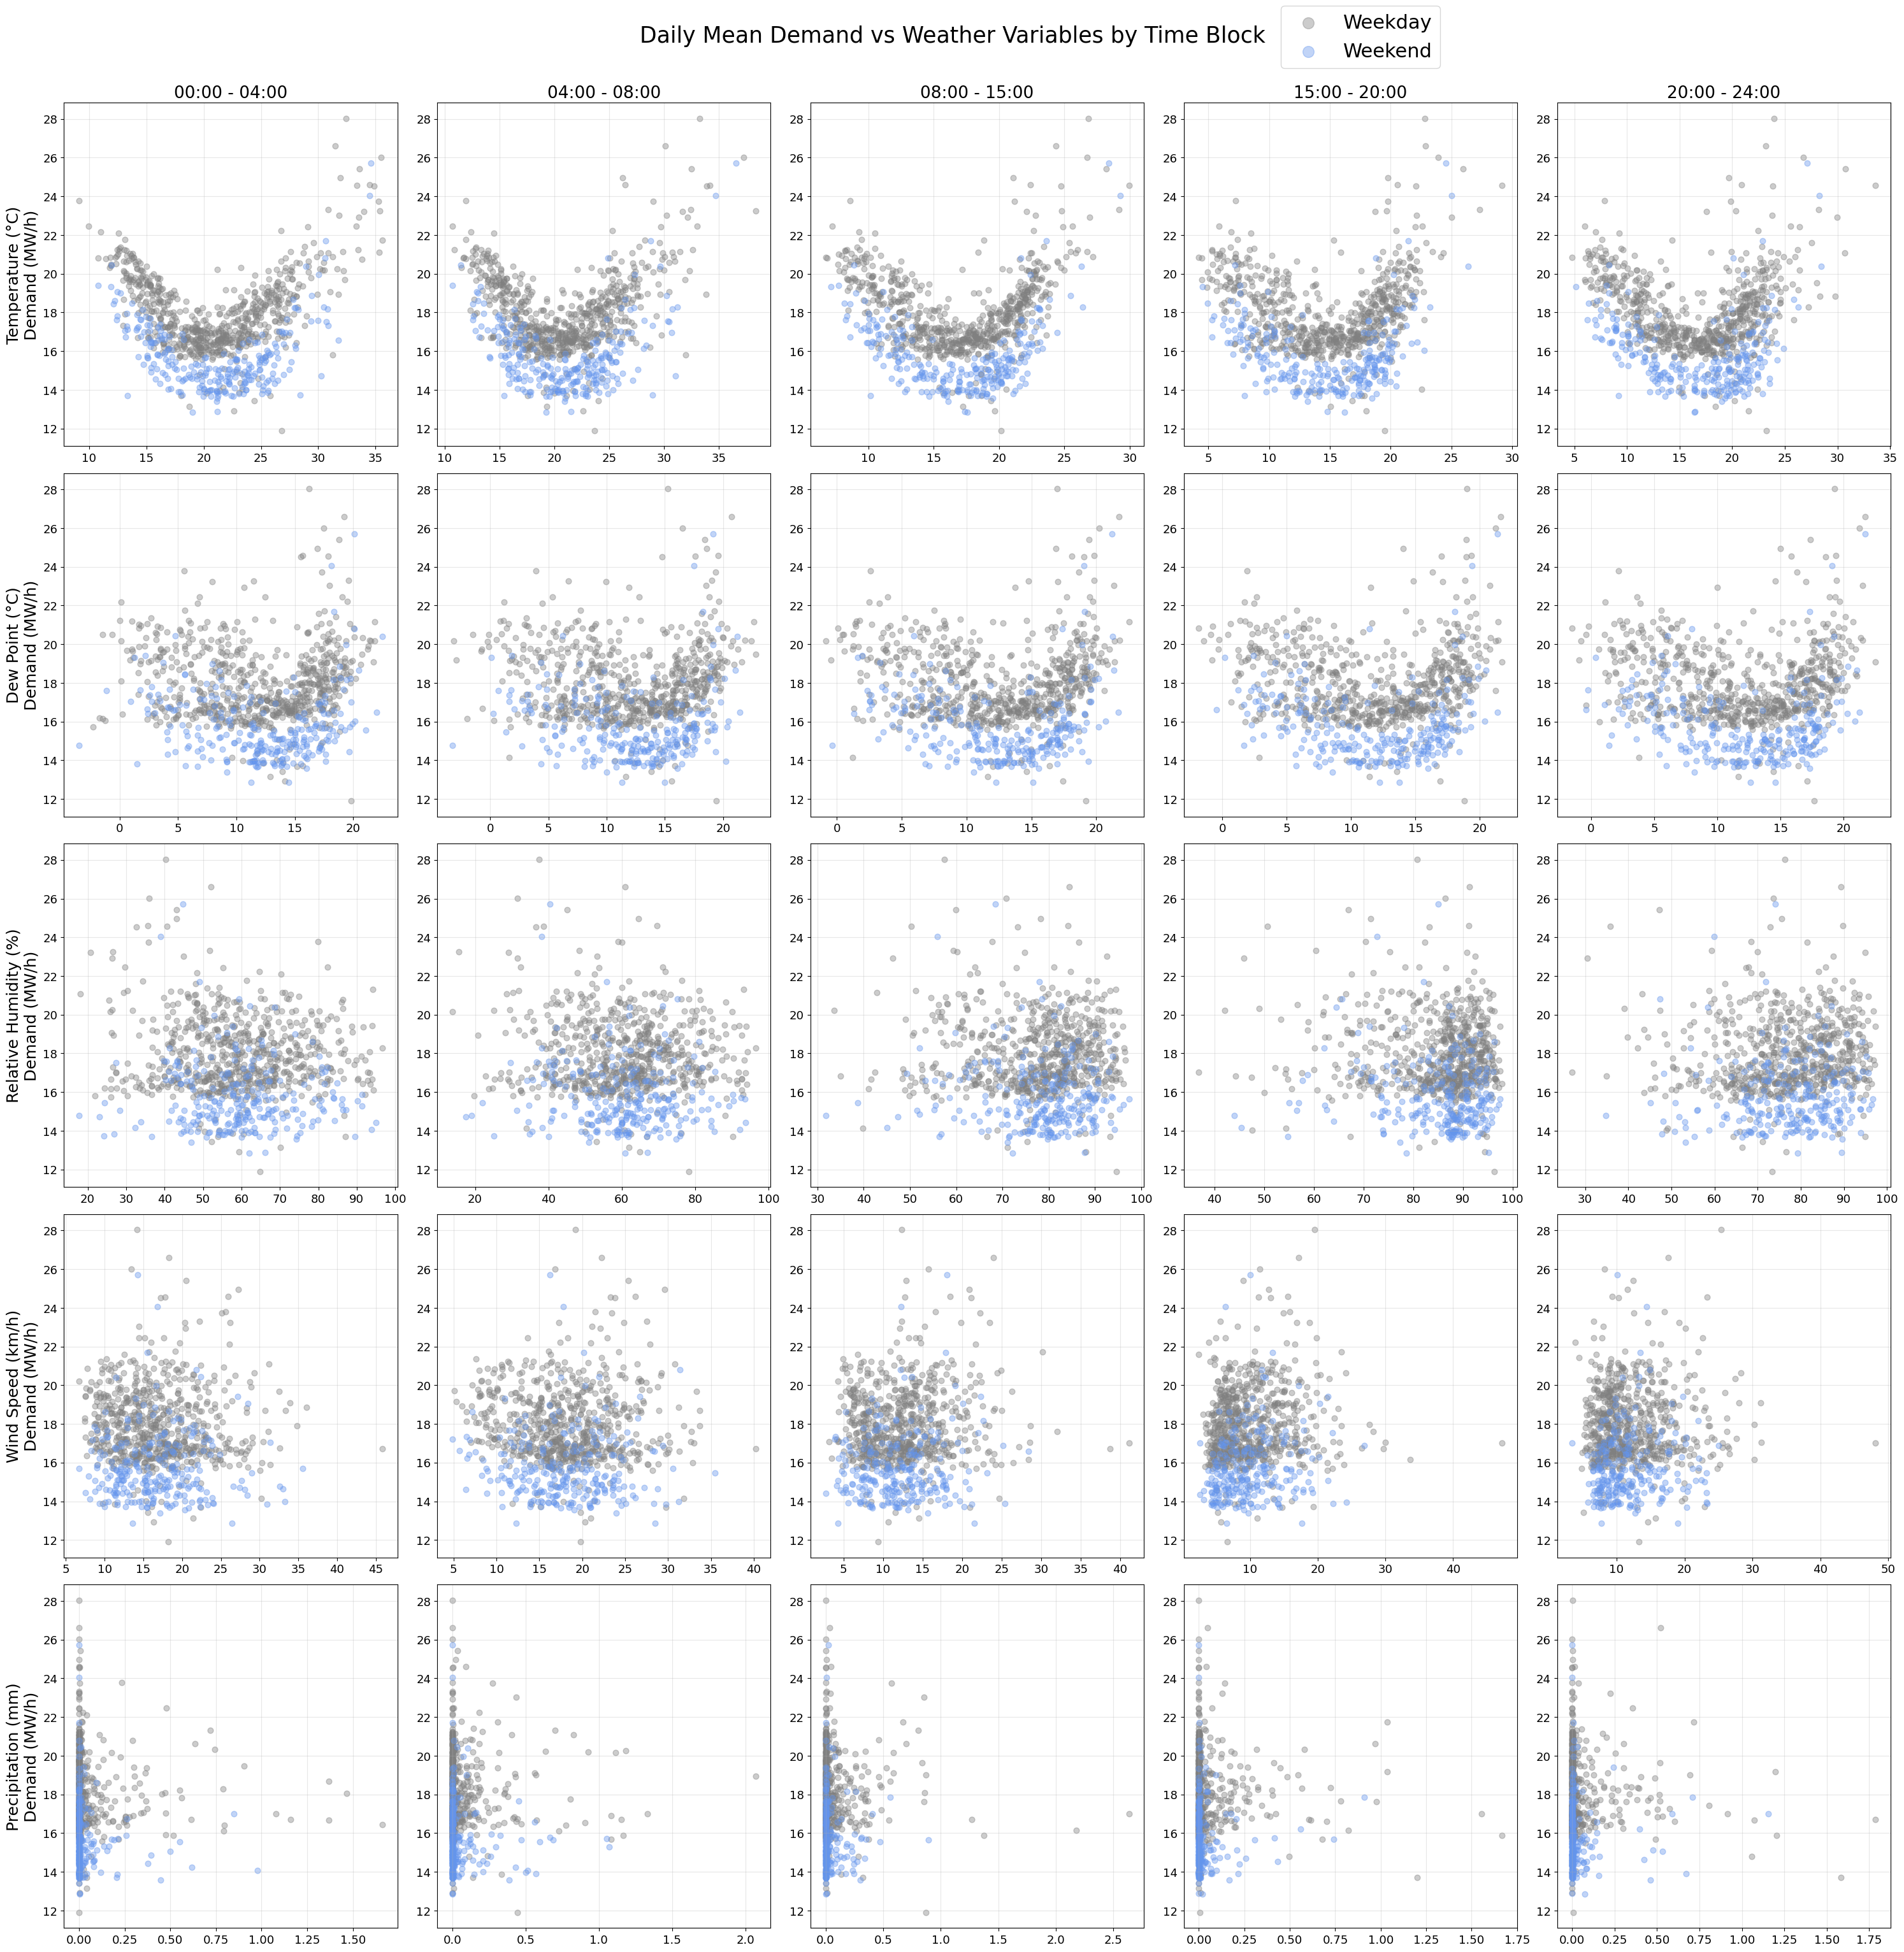

In [197]:
fig, axes = plt.subplots(5, 5, figsize=(30, 30))

for row, var in enumerate(weather_cols):
    for col, block in enumerate(block_order):
        block_data = merged_blocks[merged_blocks["time_block"] == block]
        weekday = block_data[block_data["is_weekend"] == False]
        weekend = block_data[block_data["is_weekend"] == True]

        ax = axes[row, col]

        wd = weekday[["demand_mean", var]].dropna()
        we = weekend[["demand_mean", var]].dropna()

        ax.scatter(wd[var], wd["demand_mean"], s=40, alpha=0.4, color="grey", label="Weekday")
        ax.scatter(we[var], we["demand_mean"], s=40, alpha=0.4, color="cornflowerblue", label="Weekend")

        ax.tick_params(axis="both", labelsize=13)
        ax.grid(alpha=0.3)

        # Time block labels on top
        if row == 0:
            ax.set_title(block_labels[block], fontsize=19)

        # Variable labels on left
        if col == 0:
            ax.set_ylabel(f"{var_labels[var]}\nDemand (MW/h)", fontsize=18)

        # x axis label on bottom row only
        # if row == 4:
        #     ax.set_xlabel(block_labels[block], fontsize=18)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.76, 1.025), markerscale=2, fontsize=22)

plt.suptitle("Daily Mean Demand vs Weather Variables by Time Block", fontsize=25, y=1.01)
plt.tight_layout()
plt.savefig("/home/565/pv3484/aus_substation_electricity/data/figures/thesis/data_methods/demand_vs_weather_timeblocks.png", dpi=150, bbox_inches="tight")
plt.show()